<a href="https://colab.research.google.com/github/Spurthi10/Fake-Job-Postings/blob/main/Fake_Job_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake Job Posting Detection using NLP



## Step 1 — Install & Import Libraries

In [14]:
# Install wordcloud (only needed once in Colab)
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load the Dataset

In [15]:
# ▶ If using Google Colab: upload the CSV file when prompted
# from google.colab import files
# uploaded = files.upload()

# Load dataset
df = pd.read_csv('fake_job_postings.csv.zip')

print('Dataset Shape:', df.shape)
print('\nFirst 3 rows:')
df.head(3)

Dataset Shape: (17880, 18)

First 3 rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## Step 3 — Explore the Data (EDA)

In [16]:
# Check how many real vs fake
print('Real vs Fake Job Postings:')
print(df['fraudulent'].value_counts())
print('\n0 = Real Job | 1 = Fake Job')

Real vs Fake Job Postings:
fraudulent
0    17014
1      866
Name: count, dtype: int64

0 = Real Job | 1 = Fake Job


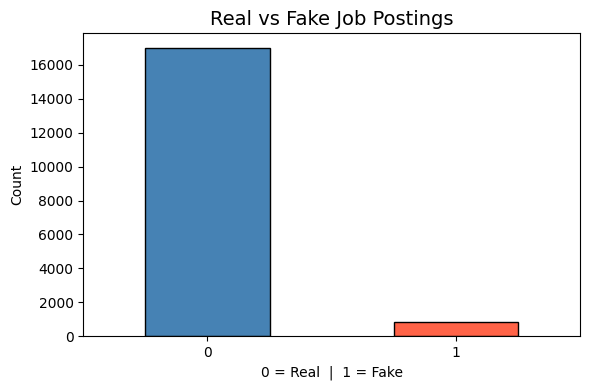

Real: 17014 | Fake: 866


In [17]:
# Plot the distribution
plt.figure(figsize=(6,4))
df['fraudulent'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Real vs Fake Job Postings', fontsize=14)
plt.xlabel('0 = Real  |  1 = Fake')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Real:', (df.fraudulent==0).sum(), '| Fake:', (df.fraudulent==1).sum())

## Step 4 — Clean & Prepare Text

In [18]:
# Combine important text columns into one
# Fill missing values with empty string
df['text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
)

# Clean text: lowercase
df['text'] = df['text'].str.lower()

print('Text column created!')
print('Sample text (first 200 chars):')
print(df['text'][0][:200])

Text column created!
Sample text (first 200 chars):
marketing intern we're food52, and we've created a groundbreaking and award-winning cooking site. we support, connect, and celebrate home cooks, and give them everything they need in one place.we have


## Step 5 — WordCloud (Fake vs Real)

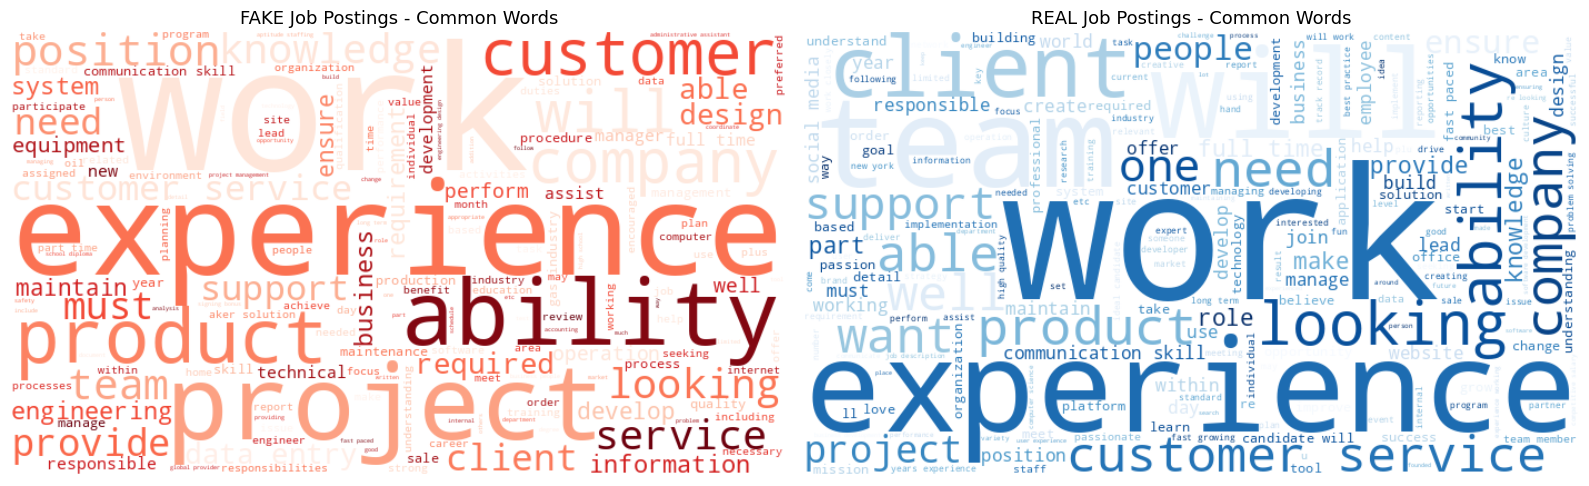

In [19]:
# WordCloud for FAKE jobs
fake_text = ' '.join(df[df['fraudulent']==1]['text'].tolist())
real_text = ' '.join(df[df['fraudulent']==0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_fake = WordCloud(width=700, height=400, background_color='white', colormap='Reds').generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('FAKE Job Postings - Common Words', fontsize=13)
axes[0].axis('off')

wc_real = WordCloud(width=700, height=400, background_color='white', colormap='Blues').generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('REAL Job Postings - Common Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

## Step 6 — Split Data into Train & Test

In [20]:
X = df['text']           # Input: text
y = df['fraudulent']     # Output: 0 or 1

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 14304
Testing samples : 3576


## Step 7 — TF-IDF Vectorization (Convert Text to Numbers)

In [21]:
# TF-IDF converts text into numbers the model can understand
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('TF-IDF done!')
print('Feature matrix shape:', X_train_tfidf.shape)

TF-IDF done!
Feature matrix shape: (14304, 5000)


## Step 8 — Train the Model (Logistic Regression)

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print('Model trained successfully!')

Model trained successfully!


## Step 9 — Evaluate the Model

In [23]:
y_pred = model.predict(X_test_tfidf)

print('=== MODEL PERFORMANCE ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred, target_names=['Real','Fake']))

=== MODEL PERFORMANCE ===
Accuracy : 97.26%

Detailed Report:
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99      3403
        Fake       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



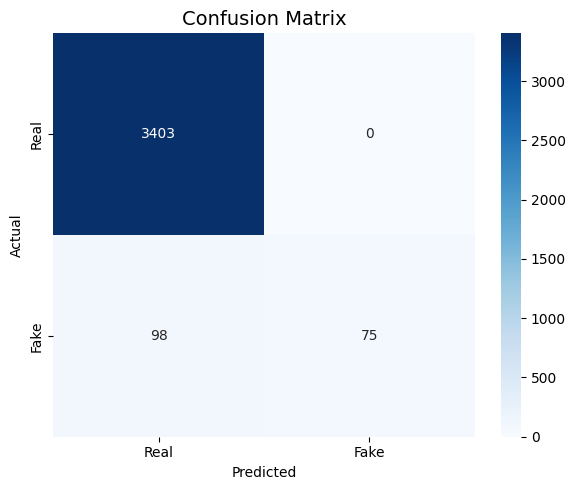

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 10 — Test with Your Own Job Posting! 🎯

In [25]:
def predict_job(title, description, requirements='', benefits=''):
    """Predict if a job posting is REAL or FAKE"""
    text = (title + ' ' + description + ' ' + requirements + ' ' + benefits).lower()
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)[0]
    probability = model.predict_proba(text_tfidf)[0]

    label = 'FAKE JOB' if prediction == 1 else 'REAL JOB'
    confidence = probability[prediction] * 100

    print(f'Result     : {label}')
    print(f'Confidence : {confidence:.1f}%')
    print(f'Real prob  : {probability[0]*100:.1f}%  |  Fake prob: {probability[1]*100:.1f}%')


# Test with a REAL-looking job
print('--- Test 1: Likely REAL ---')
predict_job(
    title='Software Engineer',
    description='We are looking for a software engineer to join our team at Google. You will work on scalable backend systems.',
    requirements='3+ years Python experience. Strong knowledge of data structures.',
    benefits='Health insurance, 401k, Remote work options'
)

print('\n--- Test 2: Likely FAKE ---')
predict_job(
    title='Work From Home Make Money Fast',
    description='Earn $5000 per week working from home! No experience needed. Just send your bank details and get started today. Guaranteed income!',
    requirements='None! Anyone can do this!',
    benefits='Unlimited income potential'
)

--- Test 1: Likely REAL ---
Result     : REAL JOB
Confidence : 96.9%
Real prob  : 96.9%  |  Fake prob: 3.1%

--- Test 2: Likely FAKE ---
Result     : FAKE JOB
Confidence : 58.1%
Real prob  : 41.9%  |  Fake prob: 58.1%


## Step 11 — Save the Model (Optional)

In [26]:
import pickle

# Save model and vectorizer
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Model saved as model.pkl')
print('Vectorizer saved as tfidf.pkl')

Model saved as model.pkl
Vectorizer saved as tfidf.pkl


---
##  Complete Project Steps

| Step | What we did |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded dataset (17,880 rows) |
| 3 | Explored data (EDA) |
| 4 | Combined text columns & cleaned |
| 5 | Visualized with WordCloud |
| 6 | Split into Train/Test |
| 7 | TF-IDF vectorization |
| 8 | Trained Logistic Regression model |
| 9 | Evaluated with accuracy + confusion matrix |
| 10 | Tested with custom job postings |
| 11 | Saved model |
